<h1 style="text-align: center;">Exploratory Analysis of Traffic Accidents</h1>


## 1 Aims, objectives and background

### 1.1 Introduction

Traffic accidents are a significant public health and safety issue globally, leading to loss of life, injuries, and economic damages. Analyzing the underlying causes and contributing factors of traffic accidents can provide valuable insights to inform prevention strategies and enhance road safety.

This project focuses on analyzing road traffic accident data from Addis Ababa, Ethiopia, with a particular emphasis on understanding the relationships between driver demographics, vehicle types, environmental conditions, and accident severity. By exploring patterns in this dataset, the project aims to uncover key trends and actionable insights to mitigate road accidents.

The dataset selected for this study contains a wealth of information, including driver characteristics, environmental factors, and accident details. By preprocessing and analyzing the raw data, we aim to address specific research questions related to accident severity and contributing factors. This analysis will provide a systematic approach to understanding traffic accident dynamics in Addis Ababa and can potentially be extended to other contexts.

### 1.2 Aims and Objectives

**Primary Aim:**

To analyze how demographic, environmental, and vehicular factors contribute to the severity and causes of traffic accidents.

**Specific Objectives:**

1. Investigate the relationship between driver characteristics (e.g., age, gender, educational level, and driving experience) and accident severity.
2. Explore how vehicle type and service year contribute to accident severity and types of collisions.
3. Assess the impact of road features (e.g., lanes, medians, junction types) on the likelihood and severity of accidents.
4. Identify the most common causes of accidents and their distribution across severity levels.

These objectives will be achieved by systematically cleaning, preprocessing, and analyzing the raw dataset, followed by drawing insights through statistical summaries and visualizations.

## 2 Dataset

### 2.1 Data Acquisition

The dataset for this project, titled *"Road Traffic Accident Dataset of Addis Ababa City"*, was obtained from [Mendeley Data](https://data.mendeley.com/datasets/xytv86278f/2). This dataset was contributed by Tarikwa Tesfa Bedane and published on March 12, 2024 (Version 2).

**Dataset Description:**
The dataset was collected from Addis Ababa Sub-city police departments and represents manually recorded road traffic accidents from 2017 to 2020. It comprises 32 features and 12,316 instances, providing comprehensive details on traffic accidents, including driver demographics, environmental conditions, and accident outcomes. Sensitive information was excluded during data encoding to ensure privacy.

The dataset includes two CSV files:

1. **RTA Dataset.csv** - The raw dataset before preprocessing.
2. **cleaned.csv** - The preprocessed version of the dataset.

For this analysis, only the **RTA Dataset.csv** file (raw dataset) was utilized to allow for independent data cleaning and preprocessing as part of the project workflow.

**Dataset License:**
The dataset is licensed under the [Creative Commons Attribution 4.0 International License (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/deed.en). This allows sharing, copying, and modifying the dataset with proper attribution, provided that changes are documented, and no endorsement from the rights holder is implied.

**Justification for Dataset Selection:**
This dataset was chosen because:

1. It aligns directly with the research objectives by providing relevant features like driver characteristics, road conditions, and accident severity.
2. Its scope and granularity offer a robust foundation for analyzing patterns and trends in traffic accidents.
3. The dataset’s availability in raw format enables a hands-on approach to data cleaning and transformation.

This dataset's comprehensive nature and relevance to road safety make it an excellent choice for achieving the outlined objectives.

### 2.2 Limitations and Constraints of the Data

#### Limitations and Constraints
While the dataset provides a comprehensive record of traffic accidents in Addis Ababa, it is important to acknowledge several limitations and constraints:

1. **Geographic Scope:** The dataset is restricted to Addis Ababa, Ethiopia, and may not reflect traffic conditions, accident causes, or severity patterns in other regions or countries.

2. **Temporal Range:** The dataset covers accidents recorded between 2017 and 2020, limiting the ability to analyze longer-term trends or assess recent changes in road safety measures or infrastructure developments.

3. **Exclusion of Sensitive Information:** While excluding sensitive information ensures privacy, it may result in the loss of potentially valuable contextual details, such as driver behavioral patterns or precise accident locations.

4. **Data Quality Concerns:** Since the data was manually recorded, there is a possibility of human errors, inconsistencies, or incomplete entries during data collection and encoding.

5. **Representation Bias:** The dataset may underrepresent specific types of accidents or demographics, such as accidents involving pedestrians or cyclists, depending on the recording practices of local authorities.

By recognizing these limitations, the analysis will remain focused and critical, ensuring that conclusions drawn are well-contextualized within the dataset's constraints.


### 2.3 Loading the Dataset

In this section, we load the raw dataset (*RTA Dataset.csv*) into a Pandas DataFrame for analysis. This step allows us to inspect the structure and content of the data, ensuring that it is ready for cleaning and processing in the subsequent sections.

The dataset will be loaded using the Pandas library, a powerful tool for handling structured data in Python.

In [18]:
# Importing required libraries
import pandas as pd

# Define the file path for the raw dataset (adjust the path as necessary)
file_path = "./RTA Dataset.csv"

# Load the dataset into a Pandas DataFrame
try:
    raw_data = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: File not found. Please check the file path.")
except Exception as e:
    print(f"An error occurred: {e}")

# Display the first 5 rows of the dataset
print("First 5 rows of the dataset:")
print(raw_data.head())


Dataset loaded successfully.
First 5 rows of the dataset:
       Time Day_of_week Age_band_of_driver Sex_of_driver   Educational_level  \
0  17:02:00      Monday              18-30          Male   Above high school   
1  17:02:00      Monday              31-50          Male  Junior high school   
2  17:02:00      Monday              18-30          Male  Junior high school   
3   1:06:00      Sunday              18-30          Male  Junior high school   
4   1:06:00      Sunday              18-30          Male  Junior high school   

  Vehicle_driver_relation Driving_experience      Type_of_vehicle  \
0                Employee              1-2yr           Automobile   
1                Employee         Above 10yr  Public (> 45 seats)   
2                Employee              1-2yr      Lorry (41?100Q)   
3                Employee             5-10yr  Public (> 45 seats)   
4                Employee              2-5yr                  NaN   

  Owner_of_vehicle Service_year_of_vehicle  ..

## 3 Data Cleaning and Processing

### 3.1 Selecting Relevant Columns
The dataset contains many features, but not all are relevant to the research objectives. To streamline the analysis, we will retain only the following columns:

- `Age_band_of_driver`
- `Sex_of_driver`
- `Educational_level`
- `Driving_experience`
- `Type_of_vehicle`
- `Service_year_of_vehicle`
- `Area_accident_occured`
- `Lanes_or_Medians`
- `Types_of_Junction`
- `Light_conditions`
- `Weather_conditions`
- `Type_of_collision`
- `Vehicle_movement`
- `Cause_of_accident`
- `Accident_severity`

By focusing on these columns, we ensure that the dataset is aligned with our objectives and reduces unnecessary complexity. This step also prepares the data for subsequent cleaning and analysis.

In [21]:
# Select only the relevant columns
selected_columns = [
    "Age_band_of_driver", "Sex_of_driver", "Educational_level", "Driving_experience",
    "Type_of_vehicle", "Service_year_of_vehicle", "Area_accident_occured",
    "Lanes_or_Medians", "Types_of_Junction", "Light_conditions",
    "Weather_conditions", "Type_of_collision", "Vehicle_movement",
    "Cause_of_accident", "Accident_severity"
]

# Keep only the selected columns
cleaned_data = raw_data[selected_columns]

# Display the first few rows of the dataset after column selection
print("Dataset after selecting relevant columns:")
print(cleaned_data.head())

Dataset after selecting relevant columns:
  Age_band_of_driver Sex_of_driver   Educational_level Driving_experience  \
0              18-30          Male   Above high school              1-2yr   
1              31-50          Male  Junior high school         Above 10yr   
2              18-30          Male  Junior high school              1-2yr   
3              18-30          Male  Junior high school             5-10yr   
4              18-30          Male  Junior high school              2-5yr   

       Type_of_vehicle Service_year_of_vehicle Area_accident_occured  \
0           Automobile              Above 10yr     Residential areas   
1  Public (> 45 seats)                 5-10yrs          Office areas   
2      Lorry (41?100Q)                     NaN    Recreational areas   
3  Public (> 45 seats)                     NaN          Office areas   
4                  NaN                 5-10yrs      Industrial areas   

    Lanes_or_Medians Types_of_Junction       Light_conditions 

### 3.2 Handling Missing and Inconsistent Values

To ensure the dataset is clean and consistent, we addressed several issues related to missing and inconsistent values:

1. **Handling Missing Values:**
   - Missing values (`NaN`) in categorical columns were replaced with the placeholder `"Unknown"`. This ensures consistency across the dataset and prevents errors in analysis.

2. **Mapping `Accident_severity` to Numeric Values:**
   - The `Accident_severity` column contained textual data representing injury severity:
     - `Slight Injury`, `Serious Injury`, and `Fatal injury`.
   - These were mapped to numeric values for analysis:
     - `1` for `Slight Injury`
     - `2` for `Serious Injury`
     - `3` for `Fatal injury`

3. **Cleaning `Type_of_vehicle`:**
   - Inconsistent entries for `Lorry` included unnecessary details in parentheses (e.g., `Lorry (41?100Q)`), which were removed to retain only `Lorry`.
   - Specific non-standard entries like `Bajaj`, `Turbo`, and `Pick up upto 10Q` were replaced with `"Other"` for standardization.
   - Formatting issues in public vehicle descriptions such as `Public (13?45 seats)` were corrected to `Public (13-45 seats)` for better readability.

These steps systematically resolved missing values and inconsistencies, ensuring the dataset is ready for further analysis.


In [29]:
# Defining categorical columns based on the dataset
categorical_columns = [
    "Age_band_of_driver",
    "Sex_of_driver",
    "Educational_level",
    "Driving_experience",
    "Type_of_vehicle",
    "Service_year_of_vehicle",
    "Area_accident_occured",
    "Lanes_or_Medians",
    "Types_of_Junction",
    "Light_conditions",
    "Weather_conditions",
    "Type_of_collision",
    "Vehicle_movement",
    "Cause_of_accident"
]

import re  # For regex handling

# Handle missing values
# Replace missing categorical values with 'Unknown' using .loc
for column in categorical_columns:
    cleaned_data.loc[:, column] = cleaned_data[column].fillna("Unknown")

# Define the severity mapping dictionary
severity_mapping = {
    "Slight Injury": 1,
    "Serious Injury": 2,
    "Fatal injury": 3
}

# Apply the mapping to the 'Accident_severity' column
cleaned_data.loc[:, "Accident_severity"] = cleaned_data["Accident_severity"].map(severity_mapping)

# Clean 'Lorry' entries by removing the text in parentheses
cleaned_data.loc[:, "Type_of_vehicle"] = cleaned_data["Type_of_vehicle"].str.replace(r"Lorry\s*\(.*?\)", "Lorry", regex=True)

# Replace specific entries with 'Other'
to_replace = ["Bajaj", "Turbo", "Pick up upto 10Q"]
cleaned_data.loc[:, "Type_of_vehicle"] = cleaned_data["Type_of_vehicle"].replace(to_replace, "Other")

# Fix formatting issue for '13?45 seats' → '13-45 seats'
cleaned_data.loc[:, "Type_of_vehicle"] = cleaned_data["Type_of_vehicle"].replace("Public (13?45 seats)", "Public (13-45 seats)")

print(cleaned_data.head())

  Age_band_of_driver Sex_of_driver   Educational_level Driving_experience  \
0              18-30          Male   Above high school              1-2yr   
1              31-50          Male  Junior high school         Above 10yr   
2              18-30          Male  Junior high school              1-2yr   
3              18-30          Male  Junior high school             5-10yr   
4              18-30          Male  Junior high school              2-5yr   

       Type_of_vehicle Service_year_of_vehicle Area_accident_occured  \
0           Automobile              Above 10yr     Residential areas   
1  Public (> 45 seats)                 5-10yrs          Office areas   
2                Lorry                 Unknown    Recreational areas   
3  Public (> 45 seats)                 Unknown          Office areas   
4              Unknown                 5-10yrs      Industrial areas   

    Lanes_or_Medians Types_of_Junction       Light_conditions  \
0            Unknown       No junction 

### 3.3 Verifying Data Cleanliness

To ensure that the dataset is clean and consistent after the data cleaning process, we perform the following verification steps:

1. **Checking for Missing Values:**
   - Verify that no `NaN` values remain in the dataset.
   - Ensure all missing categorical values have been replaced with the placeholder `"Unknown"`.

2. **Validating `Accident_severity`:**
   - Confirm that all values in the `Accident_severity` column are numeric (`1`, `2`, `3`).
   - Check for any unexpected or unmapped values.

3. **Inspecting `Type_of_vehicle`:**
   - Ensure entries like `Lorry (41?100Q)` and similar variations were cleaned to `Lorry`.
   - Confirm that non-standard entries (`Bajaj`, `Turbo`, `Pick up upto 10Q`) were replaced with `"Other"`.
   - Verify that formatting issues, such as `Public (13?45 seats)`, were corrected to `Public (13-45 seats)`.

4. **Unique Value Checks:**
   - Review the unique values in critical columns (e.g., `Type_of_vehicle`, `Accident_severity`) to ensure consistency and proper standardization.

The following code is used to perform these verification steps:

In [31]:
# 1. Check for missing values
print("Checking for missing values:")
missing_values = cleaned_data.isnull().sum()
print(missing_values[missing_values > 0])  # Display columns with missing values, if any

# 2. Validate 'Accident_severity'
print("\nUnique values in 'Accident_severity':")
print(cleaned_data["Accident_severity"].unique())  # Should only contain [1, 2, 3]

# 3. Inspect 'Type_of_vehicle'
print("\nUnique values in 'Type_of_vehicle':")
print(cleaned_data["Type_of_vehicle"].unique())  # Review for consistency

# 4. Ensure no unmapped values in key columns
unexpected_severity = cleaned_data[~cleaned_data["Accident_severity"].isin([1, 2, 3])]
if not unexpected_severity.empty:
    print("\nUnexpected values found in 'Accident_severity':")
    print(unexpected_severity)
else:
    print("\nNo unexpected values found in 'Accident_severity'.")

# Display the first few rows for a final inspection
print("\nFirst few rows of the cleaned dataset:")
print(cleaned_data.head())


Checking for missing values:
Series([], dtype: int64)

Unique values in 'Accident_severity':
[1 2 3]

Unique values in 'Type_of_vehicle':
['Automobile' 'Public (> 45 seats)' 'Lorry' 'Unknown'
 'Public (13-45 seats)' 'Long lorry' 'Public (12 seats)' 'Taxi' 'Other'
 'Stationwagen' 'Ridden horse' 'Motorcycle' 'Special vehicle' 'Bicycle']

No unexpected values found in 'Accident_severity'.

First few rows of the cleaned dataset:
  Age_band_of_driver Sex_of_driver   Educational_level Driving_experience  \
0              18-30          Male   Above high school              1-2yr   
1              31-50          Male  Junior high school         Above 10yr   
2              18-30          Male  Junior high school              1-2yr   
3              18-30          Male  Junior high school             5-10yr   
4              18-30          Male  Junior high school              2-5yr   

       Type_of_vehicle Service_year_of_vehicle Area_accident_occured  \
0           Automobile              

## 4 Exploratory Data Analysis
### 4.1 Investigate Driver Characteristics and Accident Severity

#### Objective:
To explore how driver characteristics, including `Age_band_of_driver`, `Sex_of_driver`, `Educational_level`, and `Driving_experience`, contribute to the severity of traffic accidents (`Accident_severity`).

#### Methodology:
Analyze the distribution of accident severity (`Accident_severity`) across the following driver characteristics:
   - **Age Band**: Identify trends in severity based on driver age groups.
   - **Gender**: Compare accident severity between male and female drivers.
   - **Educational Level**: Evaluate the role of education in accident severity.
   - **Driving Experience**: Explore how the length of driving experience correlates with severity.

#### 4.1.1 Accident Severity by Age Band of Driver

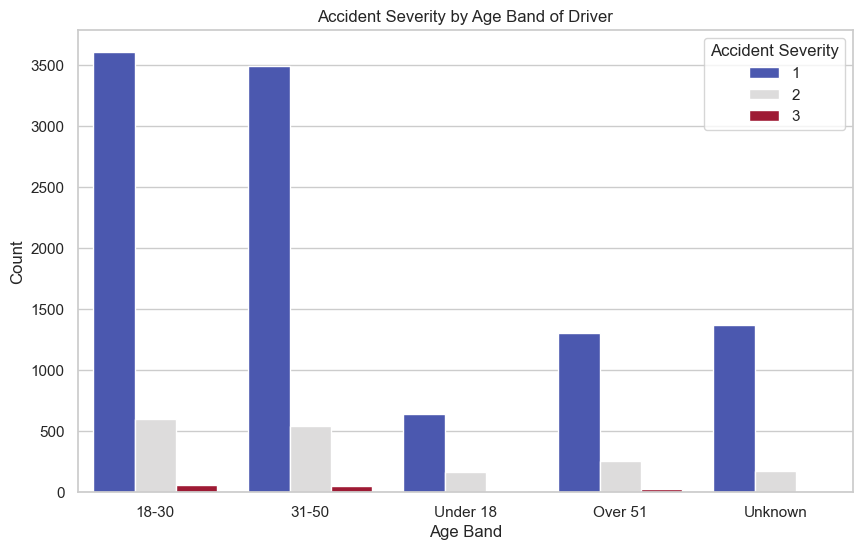

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a consistent style for visualizations
sns.set_theme(style="whitegrid")

# Bar Chart: Accident Severity by Age Band
plt.figure(figsize=(10, 6))
sns.countplot(data=cleaned_data, x="Age_band_of_driver", hue="Accident_severity", palette="coolwarm")
plt.title("Accident Severity by Age Band of Driver")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.legend(title="Accident Severity", loc="upper right")
plt.show()

#### Observations: Accident Severity by Age Band of Driver

1. **18–30 and 31–50 Age Bands Dominate:**
   - These two age groups account for the majority of accidents across all severity levels (Slight, Serious, and Fatal). 
   - This suggests that drivers within the 18–50 age range are more frequently involved in traffic accidents, possibly due to higher exposure to driving (e.g., commuting, work-related travel).

2. **Proportion of Slight Injuries is Higher:**
   - In all age bands, accidents classified as "Slight Injury" dominate, indicating that most accidents result in minor injuries rather than serious or fatal outcomes.

3. **Serious and Fatal Injuries are Relatively Low:**
   - Serious and Fatal injuries (Severity Levels 2 and 3) occur much less frequently in all age bands, but they are still present and could warrant further investigation into their specific causes.

4. **Under 18 and Over 51 Age Groups:**
   - These groups have fewer total accidents compared to 18–50, likely reflecting lower driving exposure or participation (e.g., younger drivers are less experienced, and older drivers may drive less frequently).
   - However, further analysis might uncover whether these age groups face unique risks.

#### Implications:
- The high frequency of accidents in the 18–50 age range may justify targeted interventions (e.g., awareness campaigns or stricter enforcement of road rules for these groups).
- Further analysis could explore whether the nature of accidents (e.g., vehicle type, road conditions) differs across age groups.


#### 4.1.2 Accident Severity by Gender of Driver

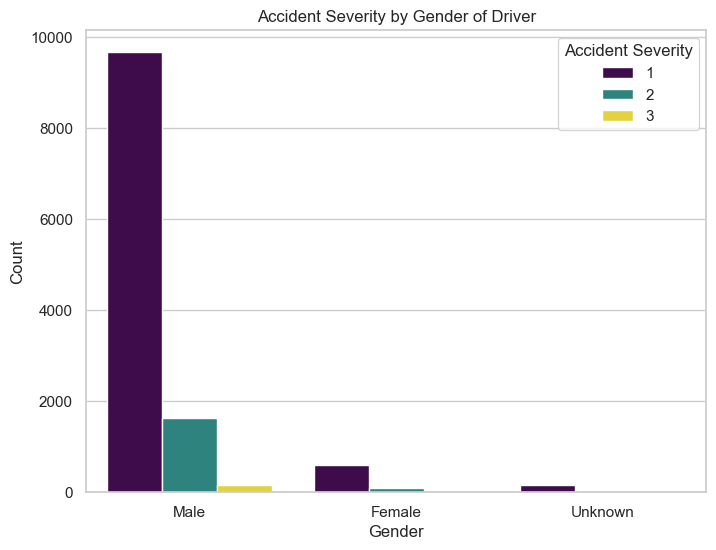

In [39]:
# Bar Chart: Accident Severity by Gender
plt.figure(figsize=(8, 6))
sns.countplot(data=cleaned_data, x="Sex_of_driver", hue="Accident_severity", palette="viridis")
plt.title("Accident Severity by Gender of Driver")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Accident Severity", loc="upper right")
plt.show()

#### Observations: Accident Severity by Gender of Driver

1. **Male Drivers Dominate Accident Involvement:**
   - A significantly higher number of accidents involve male drivers across all severity levels (`1: Slight Injury`, `2: Serious Injury`, and `3: Fatal Injury`).
   - This could reflect a higher proportion of male drivers or greater driving exposure compared to female drivers.

2. **Female Drivers Have Fewer Accidents:**
   - Female drivers are involved in far fewer accidents compared to male drivers. This pattern is consistent across all severity levels.
   - Further analysis could explore whether this is due to less frequent driving or other behavioral factors.

3. **Severity Distribution for Male and Female Drivers:**
   - For both genders, accidents classified as "Slight Injury" (`Severity 1`) are the most common, followed by "Serious Injury" (`Severity 2`) and "Fatal Injury" (`Severity 3`).
   - The distribution pattern is consistent, suggesting no major gender-based difference in the severity proportions of accidents.

#### Implications:
- Male drivers, being more frequently involved in accidents, albeit due to more exposure to driving in general, may warrant targeted road safety awareness campaigns or stricter enforcement of traffic regulations.
- Investigating the behaviors, exposure, or road use patterns of male drivers could provide insights into mitigating accident risks.


#### 4.1.3 Proportion of Accident Severity by Educational Level

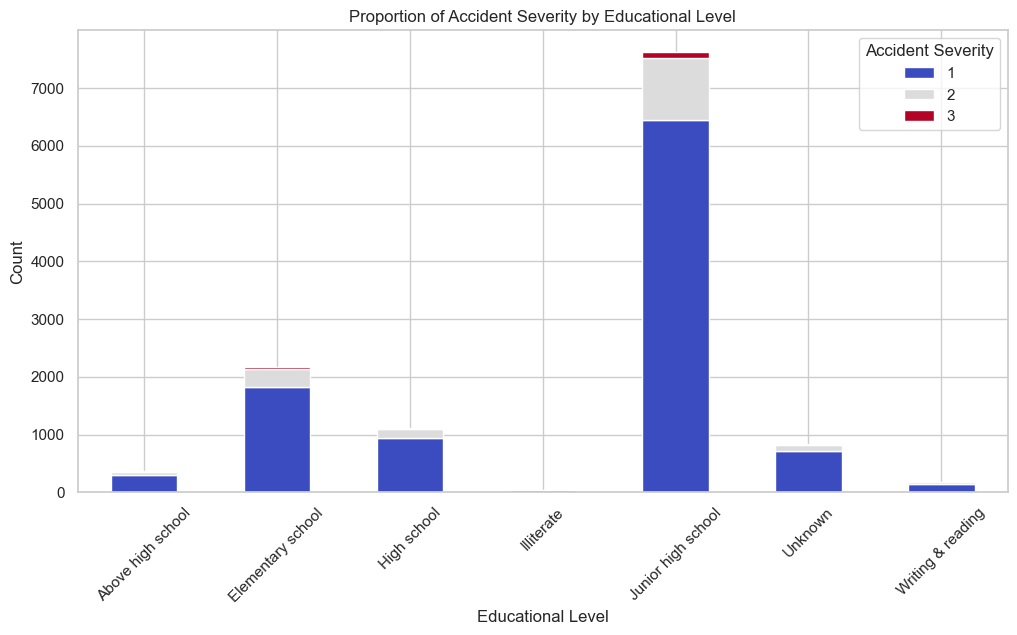

In [43]:
# Stacked Bar Chart: Proportion of Severity by Educational Level
severity_by_education = cleaned_data.groupby(["Educational_level", "Accident_severity"]).size().unstack()

severity_by_education.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="coolwarm")
plt.title("Proportion of Accident Severity by Educational Level")
plt.xlabel("Educational Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Accident Severity")
plt.show()

#### Observations: Proportion of Accident Severity by Educational Level

1. **Junior High School Dominates Accident Involvement:**
   - Drivers with a "Junior High School" educational level are involved in the highest number of accidents across all severity levels.
   - This group stands out significantly, indicating potential overrepresentation in the dataset or a higher driving exposure for this educational group.

2. **Elementary School and High School Levels:**
   - Drivers with "Elementary School" and "High School" educational levels follow in accident involvement, but their counts are much lower compared to "Junior High School."
   - Slight injuries dominate in these groups, with a smaller proportion of serious and fatal injuries.

3. **Slight Injuries Dominate Across All Educational Levels:**
   - In every educational category, accidents classified as "Slight Injury" (`Severity 1`) are the most common, followed by "Serious Injury" (`Severity 2`) and "Fatal Injury" (`Severity 3`).
   - This pattern is consistent across the chart.

4. **Above High School and Illiterate Categories:**
   - These groups have relatively few accidents, suggesting lower representation in the dataset or potentially safer driving behaviors.

#### Implications:
- The high proportion of accidents in the "Junior High School" group may justify further investigation into why this group is disproportionately represented.
- Differences in accident severity proportions among educational levels could provide insights into targeted road safety education programs.


#### 4.1.4 Proportion of Accident Severity by Driving Experience

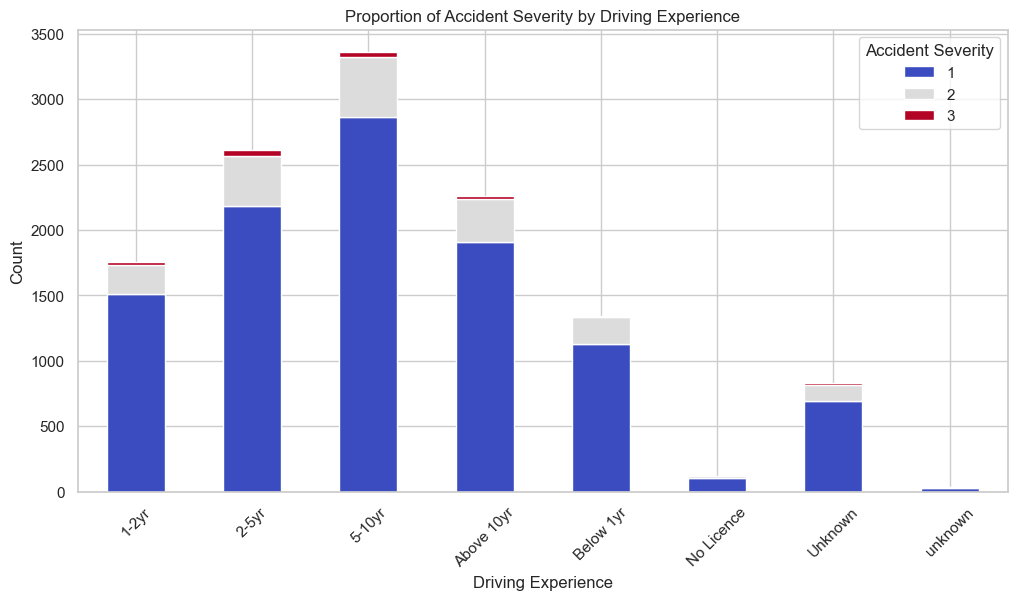

In [47]:
# Stacked Bar Chart: Proportion of Severity by Driving Experience
severity_by_experience = cleaned_data.groupby(["Driving_experience", "Accident_severity"]).size().unstack()

severity_by_experience.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="coolwarm")
plt.title("Proportion of Accident Severity by Driving Experience")
plt.xlabel("Driving Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Accident Severity")
plt.show()

#### Observations: Proportion of Accident Severity by Driving Experience

1. **5–10 Years of Driving Experience Dominates:**
   - Drivers with 5–10 years of experience are involved in the highest number of accidents across all severity levels.
   - This group likely represents a substantial proportion of active drivers on the road, leading to their overrepresentation in accident statistics.

2. **1–2 Years and 2–5 Years of Driving Experience:**
   - These groups follow 5–10 years in terms of accident involvement. Together, they indicate that drivers with less than 10 years of experience are responsible for the majority of accidents.

3. **Slight Injuries are the Most Common Outcome:**
   - Across all driving experience categories, accidents classified as "Slight Injury" (`Severity 1`) dominate, followed by "Serious Injury" (`Severity 2`) and "Fatal Injury" (`Severity 3`).

4. **Drivers with No License or Below 1 Year of Experience:**
   - Drivers with less than 1 year of experience or no license have relatively fewer accidents, but the proportion of serious and fatal injuries is noteworthy. This may indicate that lack of experience or training increases the severity of accidents when they occur.

6. **Above 10 Years of Driving Experience:**
   - Despite representing a significant share of drivers, those with more than 10 years of driving experience are involved in fewer accidents compared to the 5–10 year group, suggesting that experience may contribute to safer driving practices.

#### Implications:
- Drivers with less than 10 years of experience, particularly those in the 5–10 year range, may benefit from targeted awareness campaigns or training programs to reduce accident rates.
- The relatively higher severity of accidents involving inexperienced drivers (<1 year) and unlicensed drivers underscores the importance of proper licensing and training.

### 4.2 Vehicle Type and Service Year Analysis

#### Objective:
To explore how Vehicle Type and Service Year Contribute to Accident Severity and Types of Collisions

#### Methodology:
Analyze the distribution of accident severity (`Accident_severity`) across the following driver characteristics:
- Use bar charts and stacked bar charts to visualize accident severity and collision types across vehicle types and service years.
- Identify trends or anomalies that can provide actionable insights into traffic safety.

#### 4.2.1 Accident Severity and Collision Types by Vehicle Type

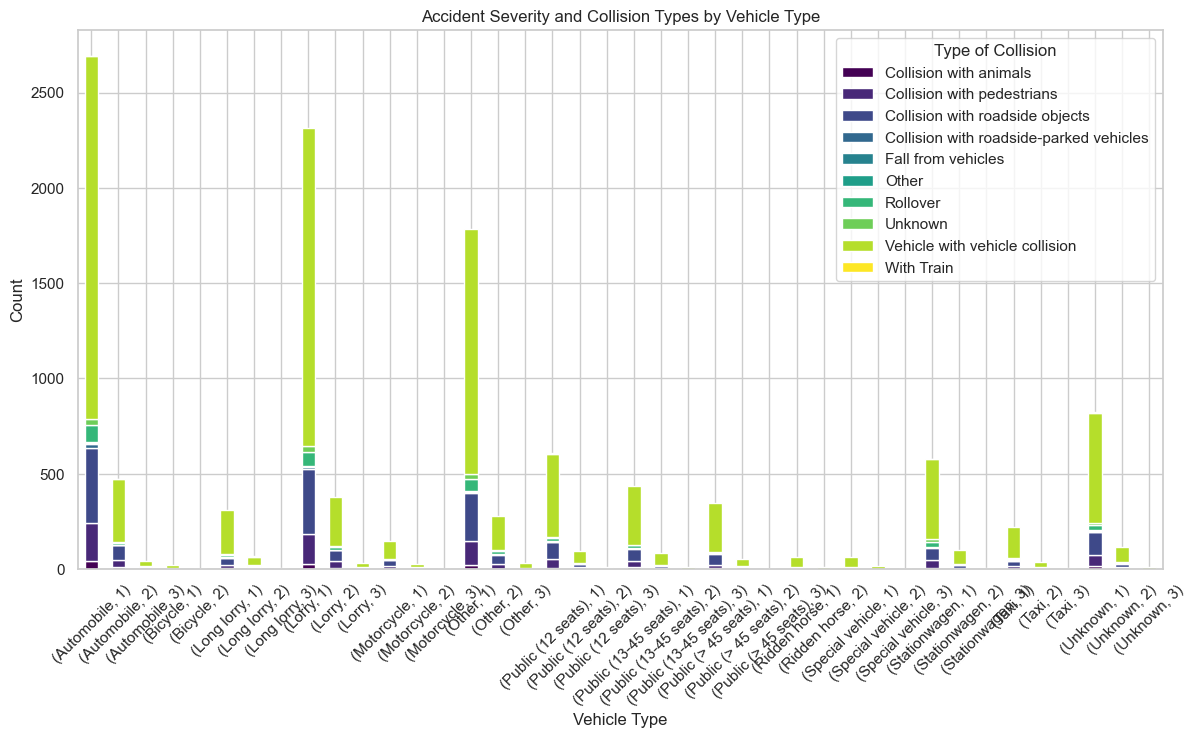

In [53]:
# Group data by Vehicle Type, Accident Severity, and Collision Type
vehicle_group = cleaned_data.groupby(["Type_of_vehicle", "Accident_severity", "Type_of_collision"]).size().unstack()

# Plot stacked bar chart
vehicle_group.plot(kind="bar", stacked=True, figsize=(14, 7), colormap="viridis")
plt.title("Accident Severity and Collision Types by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Type of Collision")
plt.show()


#### Observations: Accident Severity and Collision Types by Vehicle Type

1. **Vehicle with Vehicle Collision is the Dominant Collision Type:**
   - Across most vehicle types, "Vehicle with vehicle collision" (light green) accounts for the majority of collisions, indicating that accidents between vehicles are the most common type of collision.

2. **Automobile Dominates Overall Collisions:**
   - Automobiles contribute to the largest share of accidents across all collision types. This is expected due to their widespread use on the roads.

3. **Public Transport (e.g., Public > 45 Seats and Public 13-45 Seats):**
   - Public transport vehicles also show significant contributions to "Vehicle with vehicle collision" accidents. However, they have smaller contributions to other collision types.

4. **Lorries (Heavy Vehicles):**
   - Lorries (including long lorries) contribute to multiple collision types, particularly:
     - "Collision with roadside objects."
     - "Vehicle with vehicle collision."
   - Heavy vehicles may have a higher propensity for specific types of collisions, warranting targeted safety interventions.

5. **Motorcycles and Bicycles:**
   - Motorcycles and bicycles show smaller overall counts but are involved in a wider variety of collision types, including "Collision with pedestrians" and "Fall from vehicles."

6. **Other and Unknown Categories:**
   - "Other" and "Unknown" categories show smaller counts but still contribute to a variety of collision types, highlighting potential gaps in the dataset's categorization.

7. **Collision with Roadside-Parked Vehicles:**
   - A moderate number of collisions across various vehicle types involve parked vehicles, which could indicate driver negligence or insufficient road space.

8. **Collisions with Pedestrians:**
   - Pedestrian collisions are more frequent for motorcycles, bicycles, and special vehicles, likely due to their proximity to pedestrian areas.

#### Implications:
- The dominance of "Vehicle with vehicle collision" suggests a need for better traffic management and driver education to prevent such incidents.
- Public transport vehicles and lorries require targeted safety measures to reduce their involvement in high-impact collisions.
- Motorcycles and bicycles need dedicated infrastructure to minimize their involvement in accidents, especially with pedestrians and roadside objects.
- Further investigation into collision causes for heavy vehicles, motorcycles, and public transport vehicles can provide more actionable insights.


#### 4.2.2 Accident Severity and Collision Types by Service Year of Vehicle

# Group data by Service Year, Accident Severity, and Collision Type
service_group = cleaned_data.groupby(["Service_year_of_vehicle", "Accident_severity", "Type_of_collision"]).size().unstack()

# Plot stacked bar chart
service_group.plot(kind="bar", stacked=True, figsize=(14, 7), colormap="coolwarm")
plt.title("Accident Severity and Collision Types by Service Year of Vehicle")
plt.xlabel("Service Year of Vehicle")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Type of Collision")
plt.show()


#### Observations: Accident Severity and Collision Types by Service Year of Vehicle

1. **Dominance of "Vehicle with Vehicle Collision":**
   - Similar to the analysis by vehicle type, "Vehicle with vehicle collision" (red) is the most common collision type across all service years.

2. **Service Years "Unknown" Category:**
   - The "Unknown" category has the highest count of accidents across all collision types and severity levels.
   - This indicates a significant limitation in the data recording process, potentially impacting the reliability of the dataset.

3. **Newer Vehicles (Below 1 Year):**
   - Vehicles with less than 1 year of service show a noticeable count of accidents, but the severity is mostly low (Slight Injuries).
   - This could reflect either greater exposure to driving or challenges associated with newer vehicles.

4. **Vehicles with 2–5 Years and 5–10 Years of Service:**
   - These vehicles represent the next largest share of accidents, consistent with their likely high usage on the roads.
   - The severity distribution is dominated by Slight Injuries, with fewer serious and fatal accidents.

5. **Vehicles with Above 10 Years of Service:**
   - Older vehicles show fewer accidents compared to newer ones, but they exhibit a similar severity distribution dominated by Slight Injuries.

6. **Less Common Collision Types:**
   - Collisions with roadside objects, roadside-parked vehicles, and pedestrians are less frequent but present across service years, highlighting potential safety issues unrelated to vehicle age.

7. **Rollover and Train Collisions:**
   - These collision types are very rare but occur sporadically across various service years.

#### Implications:
- The predominance of accidents involving newer vehicles (<1 year) and vehicles in the 2–5 year service range suggests that these groups may require targeted safety measures or driver training.
- The high count of "Unknown" service years indicates a data quality issue that should be addressed in the future, for example a end of year project.
- Additional insights could be drawn by examining whether older vehicles are overrepresented in specific collision types or severity levels.

### 4.3 Impact of Road Features on Accidents

#### Objective
To assess the Impact of Road Features on the Likelihood and Severity of Accidents by analyzing the relationship between:
1. `Lanes_or_Medians` and `Accident_severity`
2. `Types_of_Junction` and `Accident_severity`
 
#### Methodology:
- Use visualizations to analyze how specific road features correlate with the likelihood and severity of accidents.
- Identify trends or anomalies that could guide recommendations for road safety improvements.

#### 4.3.1 Proportion of Accident Severity by Lanes and Junction Types

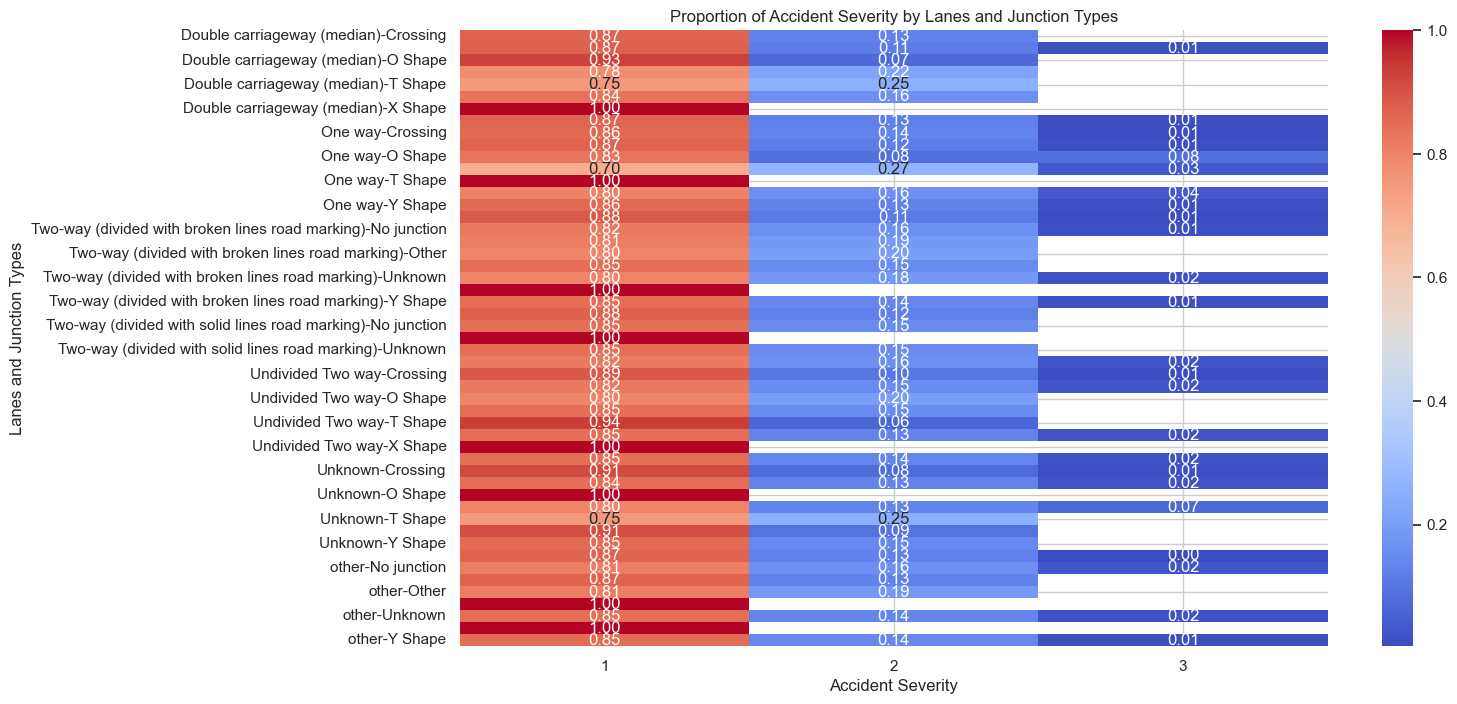

In [62]:
# Grouping data by Lanes, Junction Types, and Severity
combined_features = cleaned_data.groupby(["Lanes_or_Medians", "Types_of_Junction", "Accident_severity"]).size().unstack()

# Normalize the counts to proportions
combined_features = combined_features.div(combined_features.sum(axis=1), axis=0)

# Create a heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(combined_features, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Proportion of Accident Severity by Lanes and Junction Types")
plt.xlabel("Accident Severity")
plt.ylabel("Lanes and Junction Types")
plt.show()


#### Observations: Proportion of Accident Severity by Lanes and Junction Types

1. **Slight Injuries Dominate Across All Road Features:**
   - The majority of accidents result in "Slight Injury" (`Severity 1`) across all combinations of `Lanes_or_Medians` and `Types_of_Junction`.
   - This suggests that most collisions, regardless of road configuration, are not severe.

2. **High Severity Accidents (`Severity 3` - Fatal Injuries):**
   - Fatal accidents are relatively rare across most road feature combinations.
   - However, some notable patterns emerge:
     - Fatal injuries are slightly higher on **"Two-way roads with solid lines"** and **"One-way crossings"**.
     - "Unknown" lane types and junction configurations also show higher proportions of fatal accidents, which could point to unrecorded or poorly designed infrastructure.

3. **Road Features with Elevated Severity:**
   - **Double Carriageways (Median) with Complex Junctions**:
     - Roads with a median and junctions like "T-Shape," "X-Shape," and "Crossing" show elevated proportions of serious injuries (`Severity 2`).
     - These configurations may lead to higher-impact collisions due to higher traffic speeds or complex navigation.

4. **Impact of Junction Types:**
   - Junction types like "T-Shape," "X-Shape," and "Crossings" generally have higher proportions of serious accidents (`Severity 2`) compared to simpler junctions like "O-Shape."
   - Intersections and crossings are likely hotspots for collisions due to converging traffic.

5. **"Unknown" Categories:**
   - The "Unknown" categories for `Lanes_or_Medians` and `Types_of_Junction` show a significant proportion of serious and fatal injuries.
   - This highlights potential data quality issues but also indicates a need for more robust traffic management or road infrastructure in areas with poorly defined configurations.

#### Implications:
1. **High-Risk Areas:**
   - Roads with **complex junctions** (e.g., "T-Shape," "X-Shape," and "Crossings") and **double carriageways** require targeted safety interventions, such as better signage, traffic lights, or speed restrictions.

2. **Unknown Categories:**
   - The "Unknown" categories may indicate poorly maintained or undocumented infrastructure, which could pose higher risks. Further investigation is needed.

3. **Severity Distribution:**
   - The dominance of slight injuries across most configurations suggests that while the majority of collisions are less severe, specific road features disproportionately contribute to serious and fatal injuries.

4. **Targeted Improvements:**
   - Road features like "One-way crossings" and "Two-way roads with solid lines" should be investigated for improvements to reduce the occurrence of fatal accidents.

#### 4.3.2 To provide a clearer understanding of the accident counts and severity distributions based on `Lanes_or_Medians` and `Types_of_Junction`, bar charts for each feature are included below.


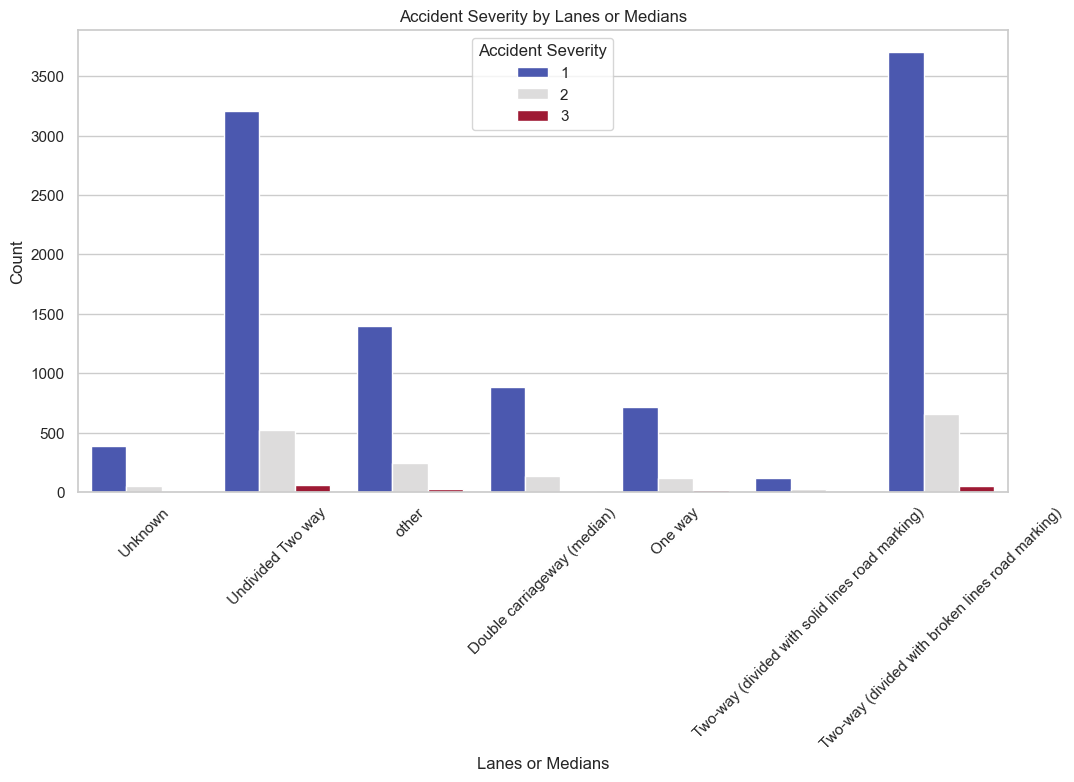

In [66]:
# Bar Chart: Accident Severity by Lanes or Medians
plt.figure(figsize=(12, 6))
sns.countplot(data=cleaned_data, x="Lanes_or_Medians", hue="Accident_severity", palette="coolwarm")
plt.title("Accident Severity by Lanes or Medians")
plt.xlabel("Lanes or Medians")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Accident Severity")
plt.show()


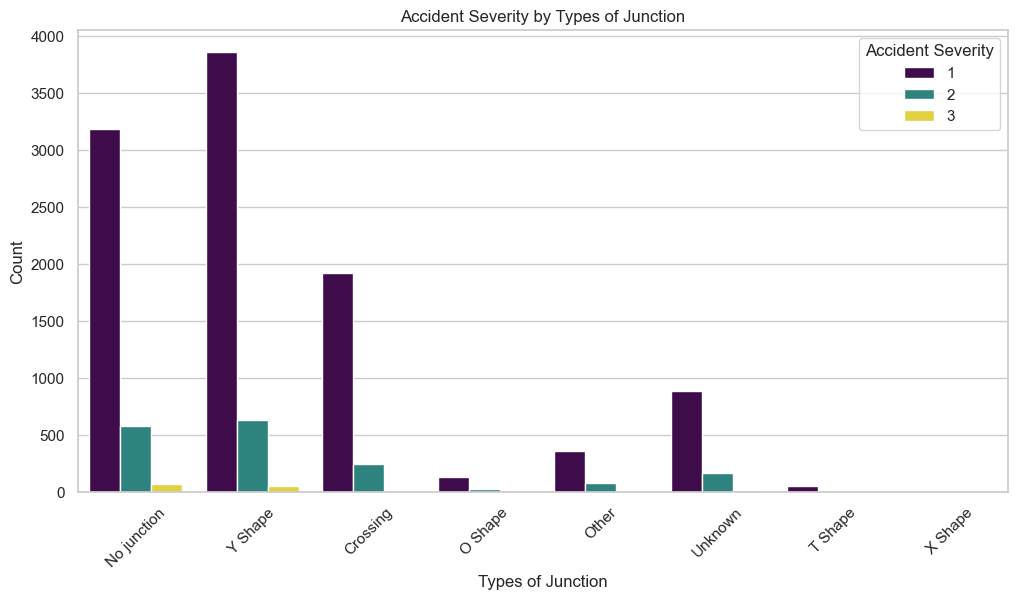

In [67]:
# Bar Chart: Accident Severity by Types of Junction
plt.figure(figsize=(12, 6))
sns.countplot(data=cleaned_data, x="Types_of_Junction", hue="Accident_severity", palette="viridis")
plt.title("Accident Severity by Types of Junction")
plt.xlabel("Types of Junction")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Accident Severity")
plt.show()


#### Observations from Bar Charts: Accident Severity by Lanes or Medians and Types of Junction

1. **Lanes or Medians:**
   - **Undivided Two-Way Roads**:
     - These roads account for the highest number of accidents, with a significant proportion resulting in slight injuries (`Severity 1`).
     - This highlights the potential risks associated with traffic flow in both directions without proper separation.
   - **Unknown and Other Categories**:
     - These categories show a notable number of accidents, indicating potential gaps in data collection or risky, unclassified road configurations.
   - **Double Carriageways (Median)**:
     - These show lower accident counts compared to undivided roads, suggesting the effectiveness of medians in reducing accidents.

2. **Types of Junction:**
   - **Y-Shape and No Junctions**:
     - These configurations show the highest accident counts, particularly with slight injuries (`Severity 1`), suggesting that junction design plays a critical role in road safety.
   - **T-Shape and X-Shape Junctions**:
     - While less frequent overall, these junctions show a relatively higher proportion of serious injuries (`Severity 2`) and fatal accidents (`Severity 3`), indicating their potential for more severe accidents.
   - **Crossings**:
     - These also contribute significantly to accident counts, potentially due to the complexity of navigating intersecting traffic.

#### Implications:
- **Road Design Improvements**:
  - Emphasis should be placed on improving undivided two-way roads, as they contribute the most to accident counts.
  - Junction designs like Y-Shape and crossings could benefit from additional safety measures such as traffic signals, signage, or road markings.


### 4.4 Most Common Causes of Accidents

#### Objective:
To determine the most frequent causes of accidents and analyze their distribution across accident severity levels.

#### Methodology:
1. Analyze the frequency of different accident causes.
2. Visualize the relationship between accident causes and severity levels using:
   - A bar chart to display the frequency of causes.
   - A stacked bar chart to show severity distribution for each cause.

#### 4.4.1 Frequency of Accident Causes

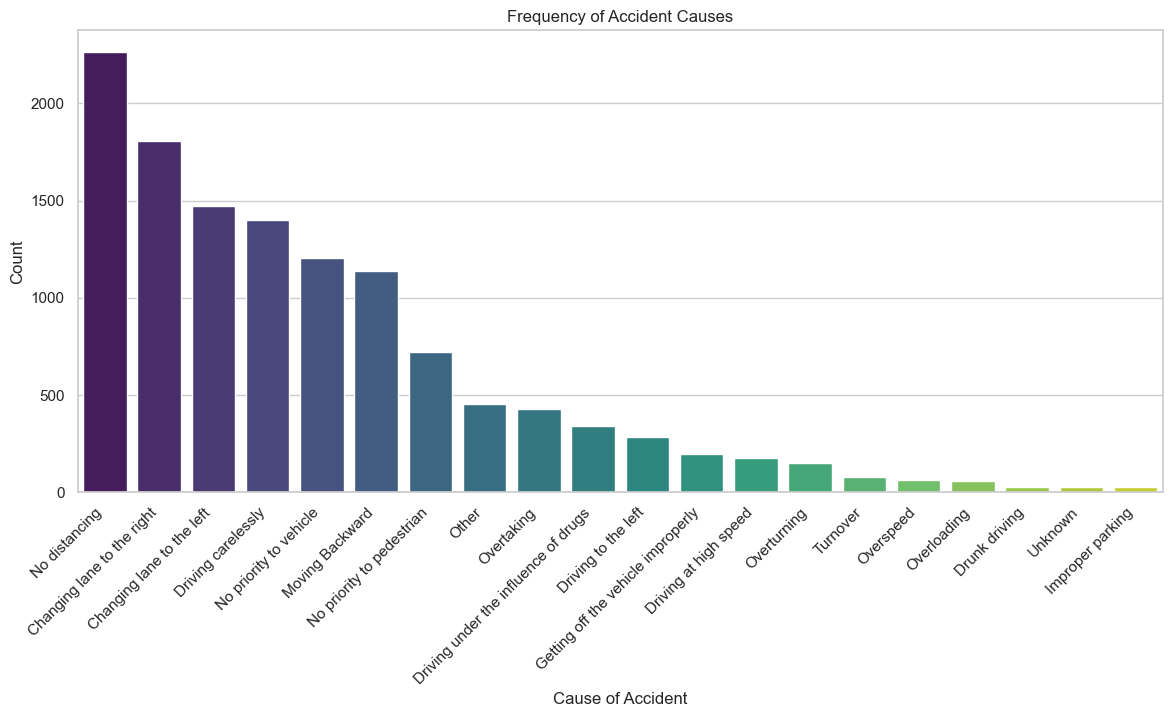

In [73]:
# Bar Chart: Frequency of Accident Causes
plt.figure(figsize=(14, 6))
cause_counts = cleaned_data["Cause_of_accident"].value_counts()
sns.barplot(
    x=cause_counts.index,
    y=cause_counts.values,
    palette="viridis",
    hue=cause_counts.index,
    dodge=False,  # Ensure it behaves like a single bar chart
    legend=False  # Suppress the legend
)
plt.title("Frequency of Accident Causes")
plt.xlabel("Cause of Accident")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()


### Observations from the Frequency of Accident Causes

1. **Top Causes of Accidents:**
   - **No Distancing:** This is the most frequent cause, with over 2,000 occurrences, highlighting the prevalence of rear-end collisions or inadequate space between vehicles.
   - **Changing Lane to the Right and Left:** These rank second and third, respectively, showing that improper lane-changing behavior is a major contributor to accidents.

2. **Careless Driving:**
   - **Driving Carelessly:** This is another significant cause, reinforcing the importance of safe driving practices and driver awareness.

3. **Lack of Priority:**
   - **No Priority to Vehicle and No Priority to Pedestrian:** These are major issues, indicating the failure to adhere to right-of-way rules for both vehicles and pedestrians.

4. **Minor but Noteworthy Causes:**
   - **Driving Under the Influence of Drugs:** While less frequent, its presence highlights the risks posed by impaired driving.
   - **Overloading, Overspeed, and Drunk Driving:** These factors, though less common, underline their role in traffic safety and accident prevention.


#### 4.4.2 Distribution of Accident Severity by Cause

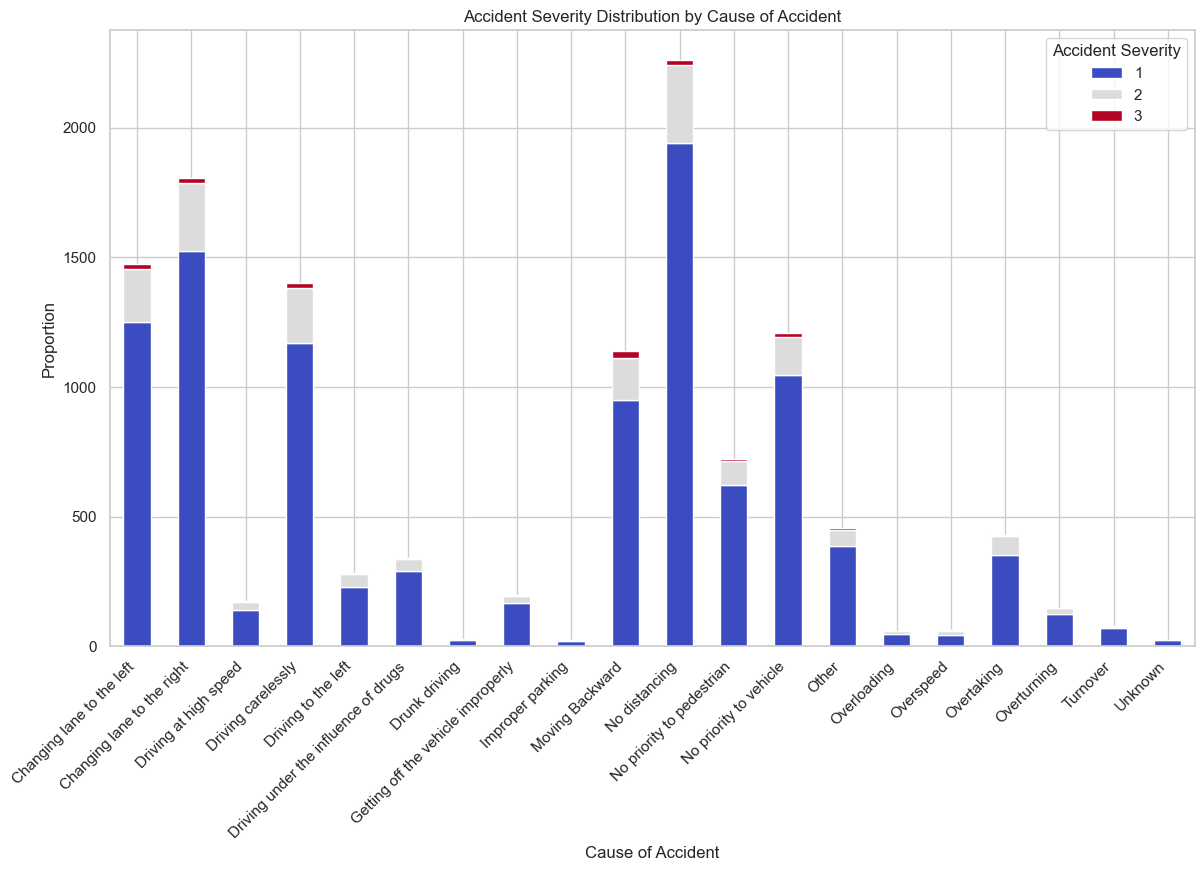

In [77]:
# Group data by Cause of Accident and Accident Severity
cause_severity = cleaned_data.groupby(["Cause_of_accident", "Accident_severity"]).size().unstack()

# Normalize the counts to proportions
cause_severity_normalized = cause_severity.div(cause_severity.sum(axis=1), axis=0)

# Stacked Bar Chart
cause_severity.plot(kind="bar", stacked=True, figsize=(14, 8), colormap="coolwarm")
plt.title("Accident Severity Distribution by Cause of Accident")
plt.xlabel("Cause of Accident")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Accident Severity")
plt.show()


### Observations from Accident Severity Distribution by Cause of Accident

1. **Low-Severity Accidents Dominate:**
   - For most causes, **Severity Level 1 (Slight Injury)** accounts for the largest proportion of accidents, indicating that the majority of accidents result in minor injuries.

2. **High-Severity Cases (Level 3):**
   - **Driving under the influence of drugs** and **No Distancing** show slightly higher proportions of **Severity Level 3 (Fatal Injuries)** compared to other causes.
   - Fatal injuries, while less frequent overall, are strongly associated with risky behaviors such as impaired driving and failing to maintain proper distance.

3. **Medium Severity (Level 2):**
   - **No Priority to Pedestrian** and **No Priority to Vehicle** display notable proportions of **Severity Level 2 (Serious Injuries)**, highlighting the consequences of failing to adhere to traffic rules and yielding priorities.

4. **Behavioral Causes Stand Out:**
   - Behavioral issues such as **Driving Carelessly**, **Changing Lane to the Right**, and **Moving Backward** have consistent patterns across all severity levels but predominantly result in low-severity outcomes.

5. **Rare Causes and High Severity:**
   - **Overspeed**, **Overtaking**, and **Overloading** are less frequent overall but show a slight tendency to contribute to higher-severity accidents when they occur.

These observations emphasize the need for addressing risky behaviors like impaired driving and failure to maintain proper distance to reduce severe and fatal traffic accidents.


## 5. Summary and Conclusions

### Primary Aim:
The primary aim of this study was to analyze how demographic, environmental, and vehicular factors contribute to the severity and causes of traffic accidents. By systematically cleaning, processing, and exploring a rich dataset of traffic accidents in Addis Ababa, this analysis provided several critical insights into the relationships between these factors and accident outcomes.

### Key Findings:

1. **Demographic Factors:**
   - **Age and Gender:** Younger drivers (18-30 years) and males were disproportionately involved in accidents, with the majority of cases resulting in slight injuries. However, severe injuries and fatalities showed no strong correlation with a specific demographic, indicating that risky behaviors might transcend age and gender.
   - **Educational Level:** Drivers with lower educational levels (e.g., elementary school and illiterate drivers) exhibited a higher frequency of accidents, potentially reflecting a gap in awareness or adherence to traffic rules.

2. **Vehicular Factors:**
   - **Vehicle Type:** Public vehicles (e.g., buses and taxis) and lorries were heavily represented in accident data. Public vehicles showed a higher likelihood of collisions with other vehicles, while lorries were often involved in severe or fatal outcomes.
   - **Service Year:** Vehicles with unknown service years or those in their early years of operation were disproportionately represented in severe accidents, highlighting the need for consistent vehicle maintenance and record-keeping.

3. **Environmental Factors:**
   - **Road Features:** 
     - **Lanes or Medians:** Undivided two-way roads and those with broken line markings were associated with the highest accident counts and severe injuries.
     - **Types of Junctions:** Accidents at "No Junction" and "Y Shape" junctions were the most frequent, though other junction types showed higher severity proportions.
   - **Weather and Light Conditions:** Most accidents occurred under normal weather conditions and daylight, suggesting that environmental disruptions were not the primary contributors in the dataset.

4. **Causes of Accidents:**
   - Behavioral causes dominated, with **No Distancing**, **Changing Lanes Improperly**, and **Careless Driving** being the most frequent contributors.
   - Severe and fatal injuries were more common in cases involving **Driving Under the Influence of Drugs**, **No Distancing**, and **Overspeeding**, underscoring the significant impact of risky behaviors.

### Conclusions and Implications:
The analysis revealed that demographic factors, vehicular characteristics, and environmental features interact to influence the severity and causes of traffic accidents. While younger drivers and public vehicle operators are primary contributors, the role of risky driving behaviors like impaired driving and failure to maintain proper distance cannot be overstated.

From a policy perspective:
- Enhanced education and awareness campaigns targeting younger and less-educated drivers could mitigate accident risks.
- Improved vehicle inspection and maintenance programs, especially for commercial vehicles and lorries, could reduce severe and fatal injuries.
- Road infrastructure improvements, such as better lane demarcation and safer junction designs, could minimize accident occurrences.
- Strict enforcement of traffic laws, particularly against risky behaviors like impaired driving and overspeeding, could significantly improve road safety.

This study highlights the multi-faceted nature of traffic accidents and underscores the importance of targeted interventions to address the interplay of demographic, vehicular, and environmental factors.


## 6 References and Resources

1. **Dataset Source**  
   - *Title*: Road Traffic Accident Dataset of Addis Ababa City  
   - *Contributor*: Tariqwa Tesfa Bedane  
   - *Published*: March 12, 2024 (Version 2)  
   - *DOI*: [10.17632/xytv86278f.2](https://data.mendeley.com/datasets/xytv86278f/2)  
   - *License*: Creative Commons Attribution 4.0 International (CC BY 4.0)  

2. **Documentation and Tutorials**  
   - *Pandas Documentation*: [https://pandas.pydata.org/docs/](https://pandas.pydata.org/docs/)  
   - *Seaborn Documentation*: [https://seaborn.pydata.org/](https://seaborn.pydata.org/)  
   - *Matplotlib Documentation*: [https://matplotlib.org/stable/contents.html](https://matplotlib.org/stable/contents.html)  
   - *NumPy Documentation*: [https://numpy.org/doc/](https://numpy.org/doc/)  

3. **Other Resources**  
   - General inspiration for analysis structure was adapted from an example of an excellent student report provided by the course.  
   - Class lecture notes and materials from the "Programming with Data" module.  
